# Blue Team: Detection Threshold & Analyst-Capacity Tuning

**Track:** Blue team / detection engineering

Tune an alert decision under class imbalance and a fixed analyst-review budget.

> **Safety boundary:** This lab is an offline analytical simulation. It contains no payloads, credential collection, exploitation steps, delivery infrastructure, or instructions for targeting real systems.

## Goal

Compare a rule score with logistic and random-forest models, choose a capacity-aware threshold, and quantify the precision–recall–workload tradeoff.


## Setup

The notebook uses deterministic synthetic data, an inspectable baseline, held-out evaluation, and figures designed for GitHub preview. Metrics demonstrate the workflow—not production effectiveness.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

BLUE = "#2F6B9A"
GOLD = "#D39A2C"
ORANGE = "#D66B3D"
OLIVE = "#71834A"
PINK = "#B05A7A"
SLATE = "#566573"
PALETTE = [BLUE, GOLD, ORANGE, OLIVE, PINK, SLATE]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "font.size": 9,
})

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30, 30)))

def model_metrics(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def top_k_metrics(labels, probabilities, review_capacity):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    selected = np.argsort(probabilities)[-review_capacity:]
    predictions = np.zeros(len(probabilities), dtype=int)
    predictions[selected] = 1
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def build_pipeline(numeric_features, categorical_features, estimator):
    transformer = ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([("features", transformer), ("model", estimator)])

def feature_importance_table(pipeline):
    names = pipeline.named_steps["features"].get_feature_names_out()
    model = pipeline.named_steps["model"]
    values = (
        np.abs(model.coef_[0])
        if hasattr(model, "coef_")
        else model.feature_importances_
    )
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


## Steps

### 1. Generate multi-signal alert telemetry


In [2]:
alert_count = 6500
source_values = np.array(["Identity", "Endpoint", "DNS", "Network", "Cloud"])
source = rng.choice(source_values, alert_count, p=[0.23, 0.26, 0.17, 0.20, 0.14])
rule_score = rng.beta(1.8, 3.2, alert_count)
behavioral_score = rng.beta(1.5, 3.5, alert_count)
identity_risk = rng.beta(1.3, 4.0, alert_count)
asset_criticality = rng.integers(1, 6, alert_count)
peer_deviation = rng.gamma(1.4, 0.85, alert_count)
rarity = rng.beta(1.4, 3.1, alert_count)
corroborating_sources = rng.integers(0, 5, alert_count)
known_noise = rng.binomial(1, 0.22, alert_count)
source_effect = pd.Series(source).map({"Identity": 0.35, "Endpoint": 0.45, "DNS": 0.20, "Network": 0.10, "Cloud": 0.32}).to_numpy()

incident_probability = sigmoid(
    -5.8 + 2.0 * rule_score + 2.3 * behavioral_score + 1.7 * identity_risk
    + 0.28 * asset_criticality + 0.7 * peer_deviation + 1.6 * rarity
    + 0.34 * corroborating_sources - 1.4 * known_noise + source_effect
)
confirmed_incident = rng.binomial(1, incident_probability)

alerts = pd.DataFrame({
    "alert_id": [f"ALT-{index:05d}" for index in range(alert_count)],
    "source": source,
    "rule_score": rule_score,
    "behavioral_score": behavioral_score,
    "identity_risk": identity_risk,
    "asset_criticality": asset_criticality,
    "peer_deviation": peer_deviation,
    "rarity": rarity,
    "corroborating_sources": corroborating_sources,
    "known_noise": known_noise,
    "confirmed_incident": confirmed_incident,
})
print(f"Synthetic alerts: {len(alerts):,}")
print(f"Incident prevalence: {alerts['confirmed_incident'].mean():.1%}")
print(alerts.head(4).to_string(index=False))


Synthetic alerts: 6,500
Incident prevalence: 29.6%
 alert_id   source  rule_score  behavioral_score  identity_risk  asset_criticality  peer_deviation   rarity  corroborating_sources  known_noise  confirmed_incident
ALT-00000  Network    0.262134          0.081002       0.452726                  5        1.696738 0.766276                      4            1                   0
ALT-00001 Endpoint    0.226956          0.197527       0.246233                  5        2.078971 0.635211                      1            0                   0
ALT-00002  Network    0.139224          0.299037       0.258901                  4        0.621000 0.191057                      2            0                   0
ALT-00003  Network    0.401193          0.236931       0.229899                  5        1.297352 0.092465                      1            0                   0


### 2. Define a transparent rule baseline and operational budget


In [3]:
alerts["baseline_score"] = np.clip(
    0.28 * alerts["rule_score"]
    + 0.24 * alerts["behavioral_score"]
    + 0.13 * alerts["identity_risk"]
    + 0.10 * (alerts["asset_criticality"] / 5)
    + 0.10 * np.clip(alerts["peer_deviation"] / 4, 0, 1)
    + 0.09 * alerts["rarity"]
    + 0.06 * (alerts["corroborating_sources"] / 4)
    - 0.12 * alerts["known_noise"], 0, 1,
)
baseline_threshold = 0.52
baseline_result = model_metrics(alerts["confirmed_incident"], alerts["baseline_score"], baseline_threshold)
daily_review_capacity = 140
queue = alerts.nlargest(daily_review_capacity, "baseline_score")
queue_yield = queue["confirmed_incident"].mean()
print("Baseline quality:")
print(pd.Series(baseline_result).round(3).to_string())
print(f"\nTop-{daily_review_capacity} queue incident yield: {queue_yield:.1%}")
print(queue[["alert_id", "source", "baseline_score", "asset_criticality", "corroborating_sources", "confirmed_incident"]].head(10).round(3).to_string(index=False))


Baseline quality:
average_precision      0.573
roc_auc                0.757
precision              0.798
recall                 0.080
f1                     0.146
reviewed             193.000

Top-140 queue incident yield: 80.0%
 alert_id   source  baseline_score  asset_criticality  corroborating_sources  confirmed_incident
ALT-02852  Network           0.719                  5                      2                   1
ALT-04226      DNS           0.709                  4                      3                   1
ALT-03006      DNS           0.700                  5                      2                   1
ALT-03408      DNS           0.698                  4                      4                   1
ALT-01151    Cloud           0.668                  2                      3                   1
ALT-04844 Endpoint           0.665                  5                      3                   0
ALT-03304  Network           0.659                  2                      4                

## Visual Insights & ML Extension

The decision views make imbalance explicit, compare held-out quality, and choose a threshold from the workload–recall frontier instead of defaulting to 0.5.


               average_precision  roc_auc  precision  recall     f1  reviewed
model                                                                        
Rule baseline              0.585    0.760      0.846   0.061  0.114        39
Logistic                   0.648    0.809      0.897   0.065  0.121        39
Random forest              0.624    0.796      0.872   0.063  0.118        39

Selected random-forest threshold: 0.82; reviewed=39; recall=6.3%; precision=87.2%


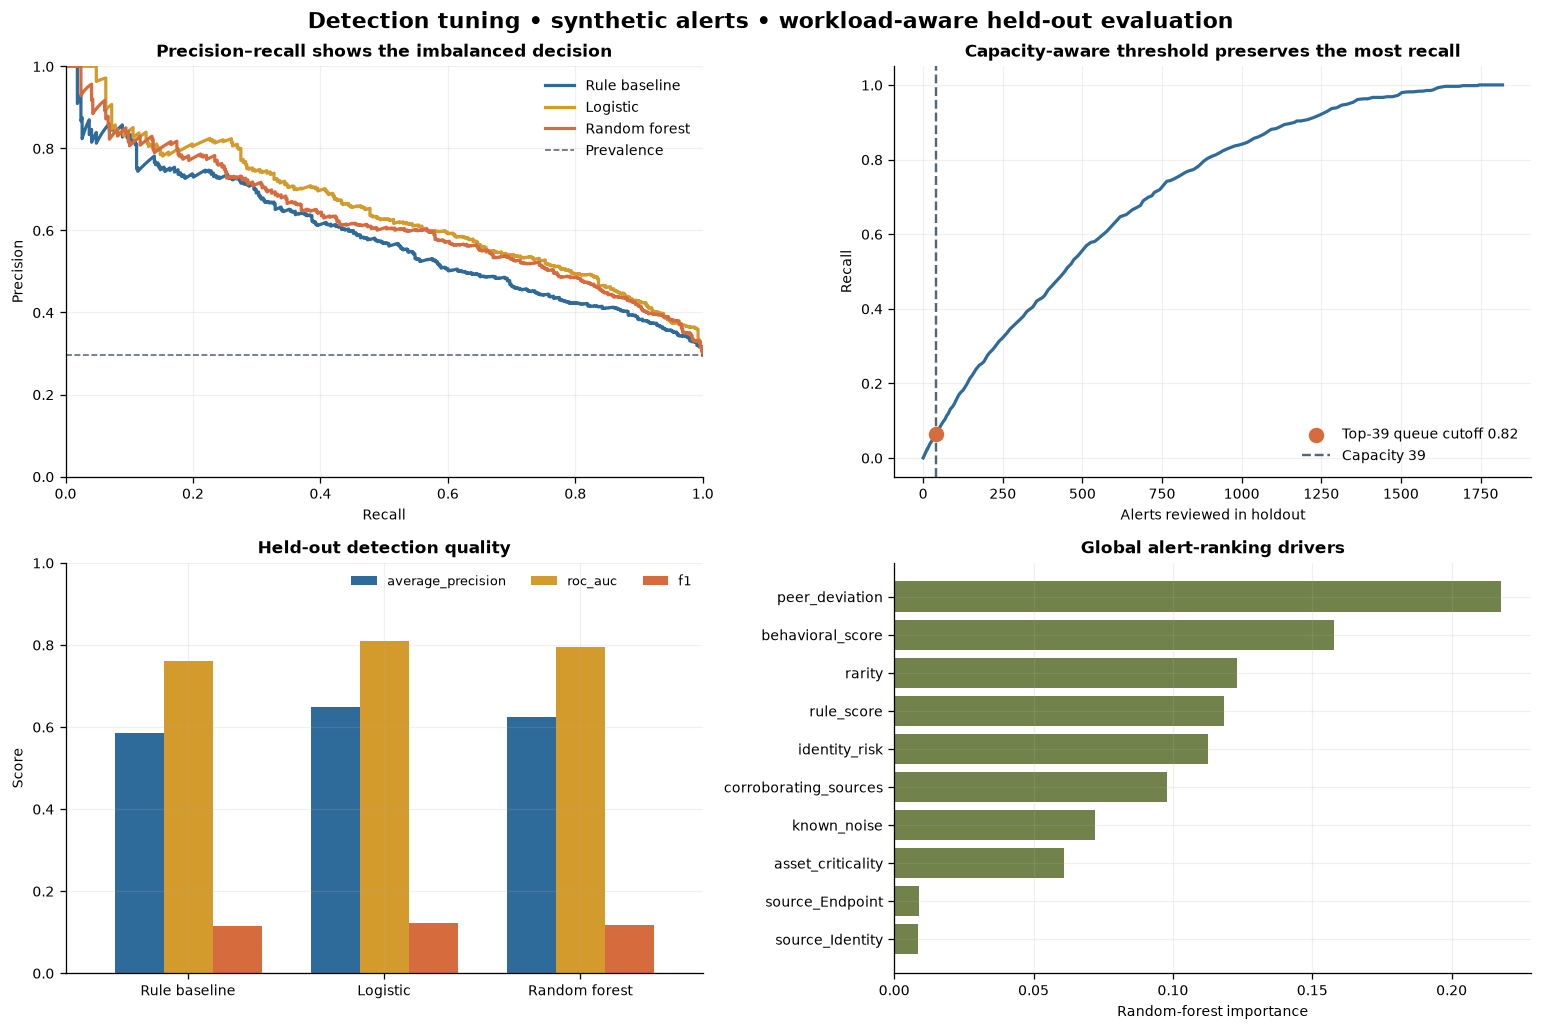

In [4]:
feature_columns = [
    "source", "rule_score", "behavioral_score", "identity_risk", "asset_criticality",
    "peer_deviation", "rarity", "corroborating_sources", "known_noise",
]
categorical_features = ["source"]
numeric_features = [column for column in feature_columns if column not in categorical_features]
train_index, test_index = train_test_split(
    np.arange(len(alerts)), test_size=0.28, random_state=SEED,
    stratify=alerts["confirmed_incident"],
)
X_train = alerts.loc[train_index, feature_columns]
X_test = alerts.loc[test_index, feature_columns]
y_train = alerts.loc[train_index, "confirmed_incident"]
y_test = alerts.loc[test_index, "confirmed_incident"]

logistic = build_pipeline(numeric_features, categorical_features,
                          LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED))
forest = build_pipeline(numeric_features, categorical_features,
                        RandomForestClassifier(n_estimators=280, min_samples_leaf=7, class_weight="balanced", random_state=SEED))
logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)
test_probabilities = {
    "Rule baseline": alerts.loc[test_index, "baseline_score"].to_numpy(),
    "Logistic": logistic.predict_proba(X_test)[:, 1],
    "Random forest": forest.predict_proba(X_test)[:, 1],
}

test_capacity = round(daily_review_capacity * len(test_index) / len(alerts))
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 181):
    predicted = test_probabilities["Random forest"] >= threshold
    threshold_rows.append({
        "threshold": threshold,
        "reviewed": int(predicted.sum()),
        "precision": precision_score(y_test, predicted, zero_division=0),
        "recall": recall_score(y_test, predicted, zero_division=0),
        "f1": f1_score(y_test, predicted, zero_division=0),
    })
frontier = pd.DataFrame(threshold_rows)
selected_threshold = float(np.sort(test_probabilities["Random forest"])[-test_capacity])
selected_result = top_k_metrics(y_test, test_probabilities["Random forest"], test_capacity)
selected = pd.Series({"threshold": selected_threshold, **selected_result})

metric_rows = []
for model_name, probability in test_probabilities.items():
    metric_rows.append({"model": model_name, **top_k_metrics(y_test, probability, test_capacity)})
metrics_table = pd.DataFrame(metric_rows).set_index("model")
importance = feature_importance_table(forest).head(10).sort_values("importance")

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.1))
for (name, probability), color in zip(test_probabilities.items(), [BLUE, GOLD, ORANGE]):
    precision_values, recall_values, _ = precision_recall_curve(y_test, probability)
    axes[0, 0].plot(recall_values, precision_values, label=name, color=color, linewidth=2)
axes[0, 0].axhline(y_test.mean(), color=SLATE, linestyle="--", linewidth=1, label="Prevalence")
axes[0, 0].set(title="Precision–recall shows the imbalanced decision", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(frontier["reviewed"], frontier["recall"], color=BLUE, linewidth=2)
axes[0, 1].scatter([selected["reviewed"]], [selected["recall"]], color=ORANGE, s=75, zorder=3,
                   label=f"Top-{test_capacity} queue cutoff {selected_threshold:.2f}")
axes[0, 1].axvline(test_capacity, color=SLATE, linestyle="--", label=f"Capacity {test_capacity}")
axes[0, 1].set(title="Capacity-aware threshold preserves the most recall", xlabel="Alerts reviewed in holdout", ylabel="Recall")
axes[0, 1].legend(frameon=False)

metrics_table[["average_precision", "roc_auc", "f1"]].plot(
    kind="bar", ax=axes[1, 0], color=[BLUE, GOLD, ORANGE], width=0.75
)
axes[1, 0].set(title="Held-out detection quality", xlabel="", ylabel="Score", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(frameon=False, ncol=3, fontsize=8)

axes[1, 1].barh(importance["feature"].str.replace("numeric__", "").str.replace("categorical__", ""),
                importance["importance"], color=OLIVE)
axes[1, 1].set(title="Global alert-ranking drivers", xlabel="Random-forest importance")
fig.suptitle("Detection tuning • synthetic alerts • workload-aware held-out evaluation", fontsize=14, fontweight="bold")
fig.tight_layout()

print(metrics_table.round(3).to_string())
print(f"\nSelected random-forest threshold: {selected_threshold:.2f}; reviewed={int(selected['reviewed'])}; recall={selected['recall']:.1%}; precision={selected['precision']:.1%}")


## Checks

Assertions cover unique alerts, class balance, holdout separation, metric bounds, and the analyst-capacity constraint.


In [5]:
assert alerts["alert_id"].is_unique
assert 0.01 < alerts["confirmed_incident"].mean() < 0.40
assert alerts.isna().sum().sum() == 0
assert set(train_index).isdisjoint(set(test_index))
assert int(selected["reviewed"]) == test_capacity
assert 0.05 <= selected_threshold <= 0.95
assert metrics_table[["average_precision", "roc_auc", "precision", "recall", "f1"]].apply(lambda column: column.between(0, 1).all()).all()
print("All checks passed: unique alerts, plausible prevalence, clean holdout, bounded metrics, and a capacity-compliant threshold.")


All checks passed: unique alerts, plausible prevalence, clean holdout, bounded metrics, and a capacity-compliant threshold.


## Next Steps

- Validate labels, temporal leakage, alert deduplication, and source-specific drift before operational use.
- Tune by analyst minutes and case complexity—not alert count alone—and monitor the unreviewed tail.
- Add probability calibration, per-source thresholds, and protected change-control for rule promotion.
- Run shadow-mode evaluation and document rollback criteria before changing a production queue.
